In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('data/criteo/criteo-uplift-v2.1.csv')

In [3]:
df.info

<bound method DataFrame.info of                  f0         f1        f2        f3         f4        f5  \
0         12.616365  10.059654  8.976429  4.679882  10.280525  4.115453   
1         12.616365  10.059654  9.002689  4.679882  10.280525  4.115453   
2         12.616365  10.059654  8.964775  4.679882  10.280525  4.115453   
3         12.616365  10.059654  9.002801  4.679882  10.280525  4.115453   
4         12.616365  10.059654  9.037999  4.679882  10.280525  4.115453   
...             ...        ...       ...       ...        ...       ...   
13979587  26.297764  10.059654  9.006250  4.679882  10.280525  4.115453   
13979588  12.642207  10.679513  8.214383 -1.700105  10.280525  3.013064   
13979589  12.976557  10.059654  8.381868  0.842442  11.029584  4.115453   
13979590  24.805064  10.059654  8.214383  4.679882  10.280525  4.115453   
13979591  12.616365  10.059654  8.214383  4.679882  10.280525  3.013064   

                 f6        f7        f8         f9       f10       

Данные содержат 12 признаков и 4 информационные метки. Всего 13 979 592 строк.

In [4]:
df.isnull().sum()

f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64

NULL-значения в данных отсутствуют.

In [5]:
df.dtypes

f0            float64
f1            float64
f2            float64
f3            float64
f4            float64
f5            float64
f6            float64
f7            float64
f8            float64
f9            float64
f10           float64
f11           float64
treatment       int64
conversion      int64
visit           int64
exposure        int64
dtype: object

Признаки имеют тип float64 (числа с плавающей запятой), бинарные метки int64 (целочисленные значения).
Корректировка типов не требуется.

In [6]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
f0,13979592.0,19.620297,5.377464,12.616365,12.616365,21.923413,24.436459,26.745255
f1,13979592.0,10.069977,0.104756,10.059654,10.059654,10.059654,10.059654,16.344187
f2,13979592.0,8.446582,0.299316,8.214383,8.214383,8.214383,8.723335,9.051962
f3,13979592.0,4.178923,1.336645,-8.398387,4.679882,4.679882,4.679882,4.679882
f4,13979592.0,10.338837,0.343308,10.280525,10.280525,10.280525,10.280525,21.123508
f5,13979592.0,4.028513,0.431097,-9.011892,4.115453,4.115453,4.115453,4.115453
f6,13979592.0,-4.155356,4.577914,-31.429784,-6.699321,-2.411115,0.294443,0.294443
f7,13979592.0,5.101765,1.205248,4.833815,4.833815,4.833815,4.833815,11.998401
f8,13979592.0,3.933581,0.056660,3.635107,3.910792,3.971858,3.971858,3.971858
f9,13979592.0,16.027638,7.018975,13.190056,13.190056,13.190056,13.190056,75.295017


Признаки f1, f8 и f11 имеют малое стандартное отклонение (0.1, 0.02 и 0.06) - имеют низкую вариативность. Признаки с наибольшим разбросом - f0, f6 и f9 (5.4, 4.6 и 7.01). Все признаки, кроме f0 и f6, имеют одинаковые или почти идентичные квантили. При этом либо min, либо max может сильно отличаться от значений в них - это говорит о наличии выбросов, возможно характерных для определенной подгруппы.

Бинарные метки также выглядят несбалансированными - для treatment во всех квантилях преобладают единицы, а для conversion, visit и exposure во всех квантилях преобладают нули. Отсюда следует, что, хотя большинство пользователей находятся в treatment-группе, целевые действия совершало и реальное воздействие получало меньшинство.

Стоит детальнее изучить распределение в признаках и баланс данных в метках.

**Распределение признаков**

<AxesSubplot:>

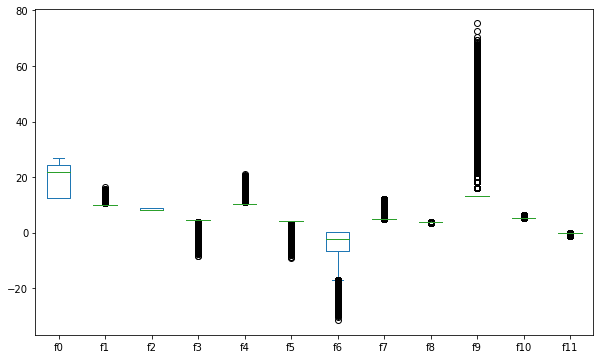

In [7]:
df.drop(['treatment','conversion','visit','exposure'], axis = 1).plot.box(figsize=(10,6))

Действительно, на boxplot-диаграммах все признаки, кроме f0 и f6, имеют крайне приплюснутые ящики с короткими усами, сливающиеся с медианой.

Все признаки, кроме f0 и f2, имеют выбросы, особенно выраженный хвост у f9. Возникает вопрос, имеют ли выбросы связь с некоторыми подгруппами.

Поскольку признаки обезличены, такие характеристики как наличие положительных и отрицательных значений не информативны.

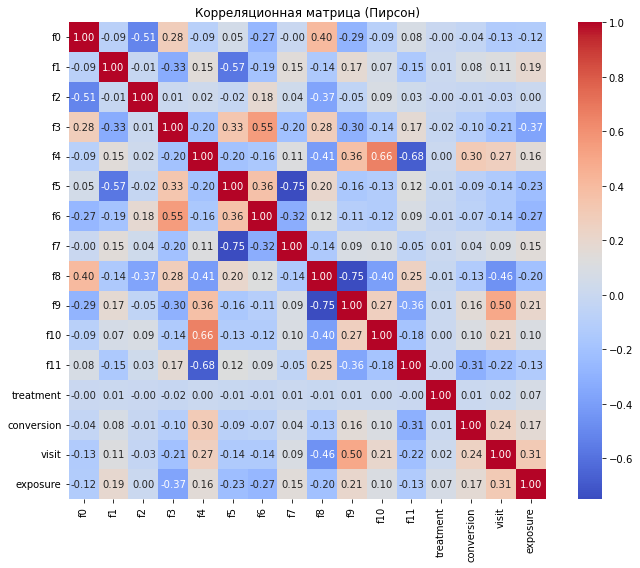

In [8]:
matrx = df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    matrx,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Корреляционная матрица (Пирсон)")
plt.tight_layout()
plt.show()

Конверсия (conversion) имеет слабую линейную зависимость от признаков, предел - 0.31 для отрицательной корреляции с признаком f11.

Более выражена корреляция посещений (visit) и признаков, особенно относительно признаков f8 и f9 (-0.46 и 0.5 соответственно).

Если "слабым" местом воронки продаж (или иного целевого действия) является этап посещения, а не конверсии, выбор признаков с такими зависимостями от этапов можно считать рациональным. Необходимо исследовать воронку для большей информации.

Некоторые признаки имеют высокую корреляцию, особенно пары f9 и f8, f5 и f7 (-0.75). Возможно, сбор таких данных излишний.

**Распределение меток**

1    0.85
0    0.15
Name: treatment, dtype: float64


<AxesSubplot:xlabel='treatment', ylabel='count'>

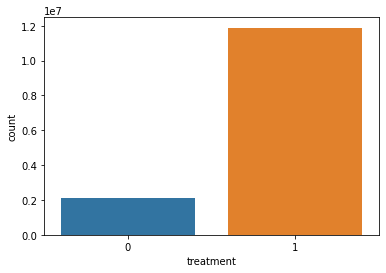

In [9]:
print(df['treatment'].value_counts(normalize=True))
sns.countplot(x='treatment', data=df)

Treatment (лечение) назначено ~85% испытуемых, распределение соответствует заявленному (84.6%). Такое распределение объяснимо для реального маркетингового эксперимента - заведомо более выигрышная стратегия может применяться к большему числу клиентов, чтобы получить меньше ущерба от менее удачной стратегии. При этом небольшая "неудачная" контрольная группа остается, чтобы оценить характер изменений, хотя статистически такое распределение менее эффективно.

0    0.997083
1    0.002917
Name: conversion, dtype: float64


<AxesSubplot:xlabel='conversion', ylabel='count'>

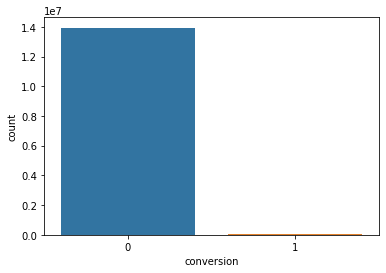

In [10]:
print(df['conversion'].value_counts(normalize=True))
sns.countplot(x='conversion', data=df)

Конверсия - крайне редкое событие, совершенное только 0.29% пользователей.

0    0.953008
1    0.046992
Name: visit, dtype: float64


<AxesSubplot:xlabel='visit', ylabel='count'>

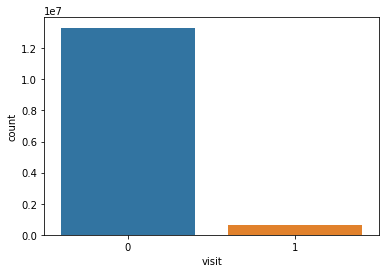

In [11]:
print(df['visit'].value_counts(normalize=True))
sns.countplot(x='visit', data=df)

Несмотря на то, что посещения происходят в несколько раз чаще конверсии, они также являются редким событием.

0    0.969369
1    0.030631
Name: exposure, dtype: float64


<AxesSubplot:xlabel='exposure', ylabel='count'>

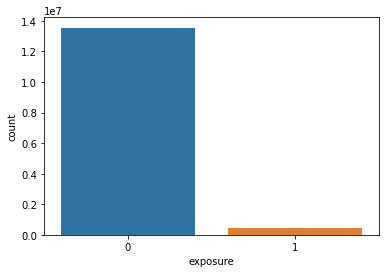

In [12]:
print(df['exposure'].value_counts(normalize=True))
sns.countplot(x='exposure', data=df)

Несмотря на преобладание пользователей, которым назначена реклама, ее фактический показ совершался лишь в  3.06% случев.

Дисбаланс, выявленный в метках, подтверждает наблюдения в раннем анализе квантилей.

**Исследование воронки**

In [13]:
pd.crosstab(df['treatment'], df['exposure'], normalize='index')

exposure,0,1
treatment,,
0,1.000000,0.000000
1,0.963963,0.036037


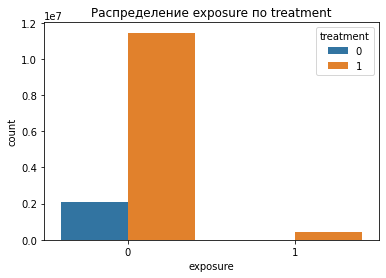

In [14]:
sns.countplot(data=df, x='exposure', hue='treatment')
plt.title('Распределение exposure по treatment')
plt.show()

В контрольной группе (treatment = 0) ожидаемо пользователи не получали реального воздействия рекламой (exposure = 1).

В экспериментальной группе (treatment = 1) большая часть пользователей также не получила фактического воздействия, несмотря на назначение.
    
Отсюда следует, что назначение рекламы дает мало гарантии, что пользователь ее увидит.


Доля conversion по treatment:
treatment
0    0.001938
1    0.003089
Name: conversion, dtype: float64


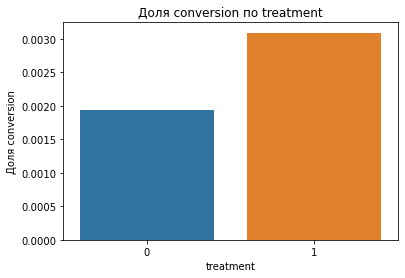

In [15]:
con_trt = df.groupby('treatment')['conversion'].mean()
print("\nДоля conversion по treatment:")
print(con_trt)

sns.barplot(
    x=con_trt.index.astype(str),
    y=con_trt.values
)
plt.xlabel('treatment')
plt.ylabel('Доля conversion')
plt.title('Доля сonversion по treatment')
plt.show()

В экспериментальной группе (treatment = 1) примерно на 1/3 чаще встречалась конверсия, даже с учетом того, что лечение не гарантирует показ (exposure = 1) рекламы пользователю. Это показывает, что для повышения конверсии даже назначение рекламы несет пользу.


Доля conversion по exposure:
exposure
0    0.001309
1    0.053784
Name: conversion, dtype: float64


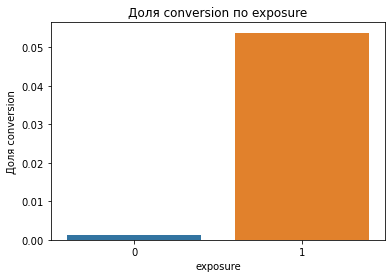

In [16]:
con_exp = df.groupby('exposure')['conversion'].mean()
print("\nДоля conversion по exposure:")
print(con_exp)

sns.barplot(
    x=con_exp.index.astype(str),
    y=con_exp.values
)
plt.xlabel('exposure')
plt.ylabel('Доля conversion')
plt.title('Доля conversion по exposure')
plt.show()

Конверсия многократно выше в случае успешного показа рекламы (exposure = 1). Отсюда можно также сделать вывод о релевантности рекламы.


Воронка: всего -> visit -> conversion:
         этап  количество      доля
0       всего    13979592  1.000000
1       visit      656929  0.046992
2  conversion       40774  0.062068


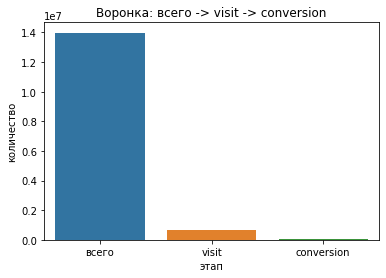

In [17]:
total = len(df)
t_visits = df['visit'].sum()
t_converions = df['conversion'].sum()

funnel = pd.DataFrame({
    'этап': ['всего', 'visit', 'conversion'],
    'количество': [total, t_visits, t_converions]
})
funnel['доля'] = funnel['количество'] / funnel['количество'].shift(1)
funnel.loc[0, 'доля'] = 1.0

print("\nВоронка: всего -> visit -> conversion:")
print(funnel)

sns.barplot(data=funnel, x='этап', y='количество')
plt.title('Воронка: всего -> visit -> conversion')
plt.show()

Из диаграммы видно, что на обоих этапах конверсионной воронки происходит резкое падение заинтересованных пользователей: 4% от всех пользователей посещают сайт, 6% пользователей из посетивших совершают конверсию.
Особенно критична малая доля пользователей на стадии посещения - их привлечение могло бы значительнее повысить конверсию на финальном этапе. Улучшение на этапе конверсии даст меньший эффект.

**Проверка рандомизации**

In [18]:
def violin_feat_split(df, features, title):
    df_plot = df.assign(_x="")

    fig, axes = plt.subplots(1, len(features), figsize=(12, 4))

    for ax, col in zip(axes, features):
        sns.violinplot(
            data=df_plot,
            x="_x",
            y=col,
            hue="treatment",
            split=True,
            inner="quartile",
            cut=0,
            linewidth=0.8,
            ax=ax
        )
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.get_legend().remove()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

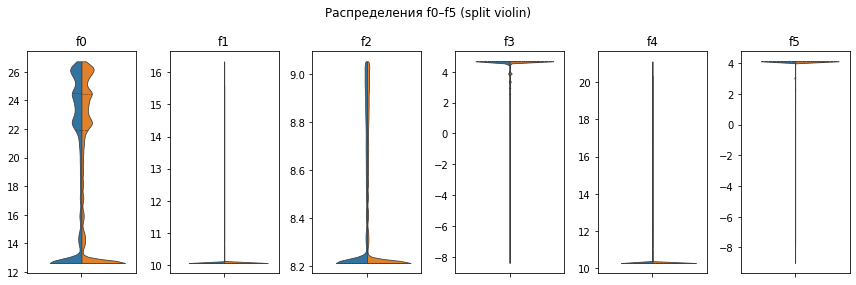

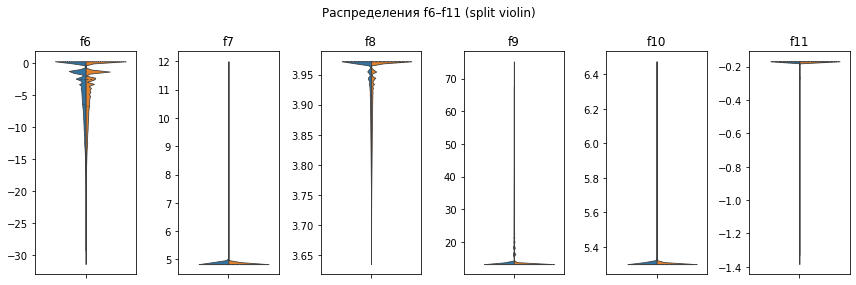

In [19]:
features_1 = [f"f{i}" for i in range(6)]
features_2 = [f"f{i}" for i in range(6, 12)]

violin_feat_split(df, features_1, "Распределения f0–f5 (split violin)")
violin_feat_split(df, features_2, "Распределения f6–f11 (split violin)")

На split-violin диаграммах видны различия в высоте пиков, которые объясняются дисбалансом размеров групп. Однако в формах распределений различий не наблюдается - распределения признаков между контрольной и экспериментальной группой симметричны.

Можно вычислить SMD (standardized mean difference) для количественной проверки.

In [20]:
def smd(df, features, trt_col="treatment"):
    g = df.groupby(trt_col)[features]
    mean = g.mean()
    var = g.var()
    smd = (mean.loc[1] - mean.loc[0]) / np.sqrt((var.loc[1] + var.loc[0]) / 2)
    return smd.sort_values(key=np.abs)

features = [f"f{i}" for i in range(12)]
smd = smd(df, features)
smd

f11   -0.005160
f2    -0.006241
f0    -0.006866
f4     0.007966
f10    0.010563
f7     0.021270
f8    -0.022433
f1     0.023994
f9     0.024001
f5    -0.030557
f6    -0.040448
f3    -0.048836
dtype: float64

Модуль всех значений меньше 0.1, что снова говорит о хорошем балансе. Этих проверок достаточно, чтобы убедиться в корректности рандомизации.

### **РЕЗУЛЬТАТЫ EDA**

    В ходе анализа не было выявлено NULL значений, некорректных типов данных и несоответствий описанию датасета, распределение признаков между группами сбалансировано - данные готовы к работе.
    
    Выявлен дисбаланс в метках, а также выбросы в 10 из 12 признаков и высокая корреляция в некоторых признаках - важно учесть эти особенности при выборе модели.

    Анализ воронки показал, что ее наиболее критичным и слабым местом является посещение сайта (visit) пользователями. На данном этапе допустимо предположить, что проблема в низком числе exposure, поскольку в случае воздействия рекламой конверсия значительно повышается, а назначение рекламы дает мало гарантии, что пользователь ее увидит.


В ходе анализа возникли вопросы, которые не будут разобраны в данном проекте, но могут стать основой для других исследований:
1. Связаны ли выбросы с определенными подгруппами – например, пользователями с высокой вероятностью конверсии или наоборот с пользователями, негативно реагирующими на воздействие?
2. Можно ли удалить сильно коррелирующие признаки - как это повлияет на модели и какие признаки из коррелирующих лучше оставить?